API 功能：

drawdown.plot(...)：pandas 的绘图 API，底层调用 matplotlib。

figsize=(10,4)：图像大小，宽 10 英寸，高 4 英寸。

(10,4) 是 Python 元组。

color="black"：线条颜色为黑色。

title="Drawdown Curve"：图表标题。

ax：matplotlib 的 Axes 对象，后续可以继续设置坐标轴、填充区域等。

语法：连续访问对象属性和方法：

ax.yaxis：取得 y 轴对象。

.set_major_formatter(...)：设置 y 轴主刻度显示格式。

mtick.PercentFormatter(1.0)：创建百分比格式化器。

API 功能：把 y 轴数值显示成百分比。因为 drawdown 的值是小数比例，这里的 1.0 表示：输入数据 1.0 对应 100%。

159915 max drawdown: -56.67%


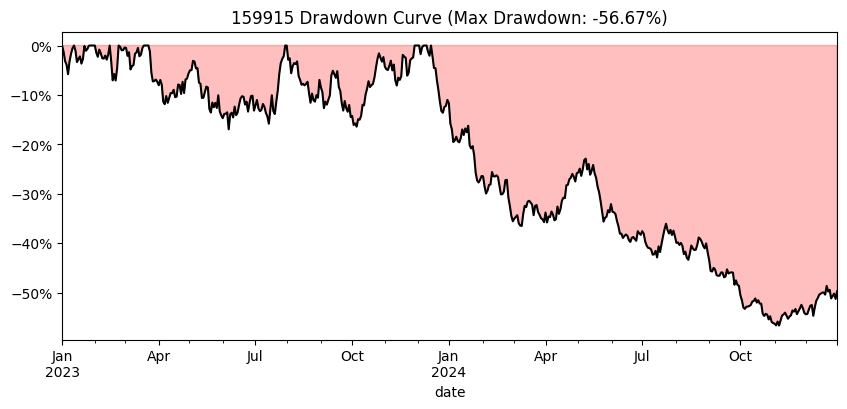

510300 max drawdown: -29.41%


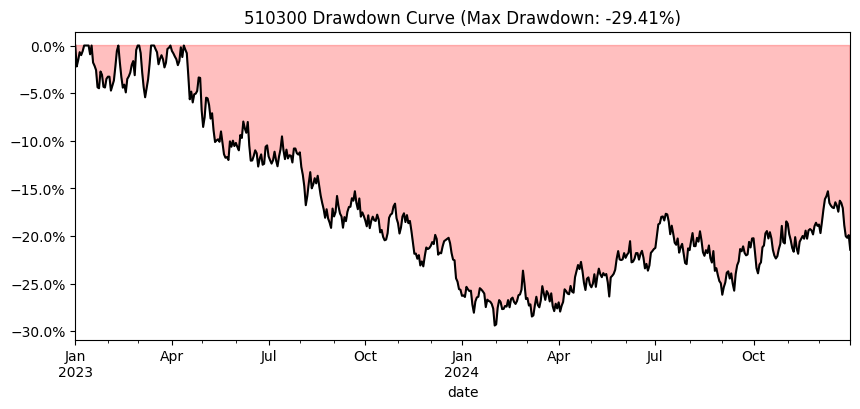

511010 max drawdown: -4.15%


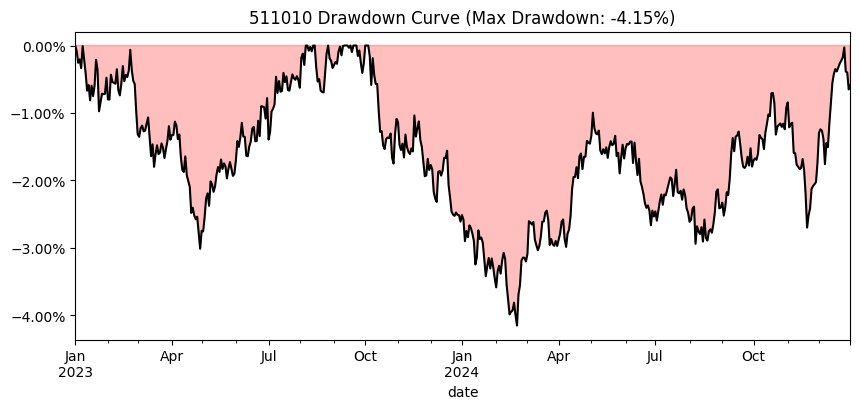

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = pd.read_csv("../data/sample_etf_daily.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"], ascending=[True, True])

for symbol, group in df.groupby("symbol"):
    group = group.sort_values("date").dropna(subset=["close"]).set_index("date")
    if group.empty:
        continue

    cummax = group["close"].cummax()
    drawdown = group["close"] / cummax - 1
    max_drawdown = drawdown.min()
    print(f"{symbol} max drawdown: {max_drawdown:.2%}")

    ax = drawdown.plot(
        figsize=(10, 4),
        color="black",
        title=f"{symbol} Drawdown Curve (Max Drawdown: {max_drawdown:.2%})",
    )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.fill_between(
        drawdown.index,
        drawdown.values,
        0,
        where=drawdown.values < 0,
        color="red",
        alpha=0.25,
        interpolate=True,
    )
    plt.show()


你最该记住的知识点

波动率 = 收益率的标准差

年化波动率：
年化波动率 = 单期收益率标准差 × sqrt(一年有多少期)

日频数据通常：
年化波动率 = 日收益率标准差 × sqrt(252)

夏普比率：
夏普 = 年化超额收益 / 年化波动率

代码里常写成：
夏普 = 超额收益均值 / 超额收益标准差 × sqrt(252)

其中：
超额收益 = 策略收益率 - 无风险收益率

如果暂时不考虑无风险收益率，就相当于：
超额收益 ≈ 策略收益率

别只看收益率，收益高但波动大，可能只是坐过山车；夏普就是用来问一句：你每承担一份波动，换来了多少收益？ 哼，这才像个认真做回测的人。

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/sample_etf_daily.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"], ascending=[True, True])
df["ret"]=df.groupby("symbol")["close"].pct_change()


for symbol, group in df.groupby("symbol"):
    if group.empty:
        continue

    daily_vol=group["ret"].std()
    print(f"{symbol} daily volatility: {daily_vol:.2%}")
    annual_vol=daily_vol*np.sqrt(252)
    print(f"{symbol} annual volatility: {annual_vol:.2%}")
    sharpe_ratio=group["ret"].mean()/daily_vol*np.sqrt(252)
    print(f"{symbol} annualized Sharpe ratio: {sharpe_ratio:.2f}")


159915 daily volatility: 1.86%
159915 annual volatility: 29.55%
159915 annualized Sharpe ratio: -0.49
510300 daily volatility: 1.12%
510300 annual volatility: 17.81%
510300 annualized Sharpe ratio: -0.32
511010 daily volatility: 0.20%
511010 annual volatility: 3.15%
511010 annualized Sharpe ratio: 0.33


## 月度收益和年度收益表

月度收益和年度收益都应该用每日收益率复利聚合：

```text
区间收益率 = (1 + 第1天收益率) * (1 + 第2天收益率) * ... * (1 + 最后1天收益率) - 1
```

不要直接把每日收益率简单相加。

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/sample_etf_daily.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"], ascending=[True, True])
df["ret"]=df.groupby("symbol")["close"].pct_change()

returns_df = df.dropna(subset=["ret"]).copy()
returns_df["year"] = returns_df["date"].dt.year
returns_df["month"] = returns_df["date"].dt.month

monthly_returns = (
    returns_df.groupby(["symbol", "year", "month"])["ret"]
    .apply(lambda ret: (1 + ret).prod() - 1)
    .rename("monthly_return")
    .reset_index()
)

annual_returns = (
    returns_df.groupby(["symbol", "year"])["ret"]
    .apply(lambda ret: (1 + ret).prod() - 1)
    .rename("annual_return")
    .reset_index()
)

monthly_return_table = monthly_returns.pivot_table(
    index=["symbol", "year"],
    columns="month",
    values="monthly_return",
)
monthly_return_table = monthly_return_table.reindex(columns=range(1, 13))
monthly_return_table.columns = [f"{month:02d}" for month in monthly_return_table.columns]
monthly_return_table["year_return"] = annual_returns.set_index(["symbol", "year"])["annual_return"]

annual_return_table = annual_returns.pivot(
    index="year",
    columns="symbol",
    values="annual_return",
)

print("Monthly return table")
display(monthly_return_table.style.format("{:.2%}"))

print("Annual return table")
display(annual_return_table.style.format("{:.2%}"))


KeyError: ['ret']